## Foreign Gifts: Initial Analysis
#### *Name: Anna Phillips*

In [2]:
## Import packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### A. Load Foreign Gifts data

In [3]:
## Load the data
df = pd.read_csv("ForeignGifts_edu.csv", low_memory=False)

## Preliminary exploration
print(df.shape)
df.head()

(28221, 10)


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [4]:
## Examine Dataframe Schema
display(df.columns)

display(df.dtypes)

Index(['ID', 'OPEID', 'Institution Name', 'City', 'State',
       'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type',
       'Country of Giftor', 'Giftor Name'],
      dtype='str')

ID                            int64
OPEID                         int64
Institution Name                str
City                            str
State                           str
Foreign Gift Received Date    int64
Foreign Gift Amount           int64
Gift Type                       str
Country of Giftor               str
Giftor Name                     str
dtype: object

### B. Describe differences between classes of gift types

There are three gift types:\
    1. **Contract**: Money given to universities in exchange for services or deliverables (e.g., research grants, instructional services)\
    2. **Monetary Gift**: Money given to universities (sometimes with conditions like sponsoring a scholarship or department, but not an official contract)\
    3. **Real Estate**: Property gifted to universities

All three gift types are represented in US dollar amounts in the `Foreign Gift Amount` column.

*Data background: Monetary gifts from a single foreign source given to a US university that totals $250,000 or more (separately -- or all together in one calendar year) must be reported to the US Department of Education via [Section 117 of the Higher Education Act](https://www.congress.gov/crs-product/IF12927).*

### C. Analysis Questions

A) What country gives the most money in total?

In [5]:
# Group by country, sum gift amount, and sort
country_money = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Display head to confirm format
display(country_money.head())

# Use indexing to report details for top country
print(
    "Country that gives the most money in total: ",
    country_money.iloc[0]["Country of Giftor"],
    f"(${country_money.iloc[0]["Foreign Gift Amount"]:,.0f})",
)

,Country of Giftor,Foreign Gift Amount
0,QATAR,2706240869
1,ENGLAND,1464906771
2,CHINA,1237952112
3,SAUDI ARABIA,1065205930
4,BERMUDA,899593972


Country that gives the most money in total:  QATAR ($2,706,240,869)


B) Which country initiates the most gifts by count?

In [6]:
# Group by country, count total gifts, and sort
country_count = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
)

# Display head to confirm format
display(country_count.head())

# Use indexing to report details for top country
print(
    "Country that initiates the most gifts: ",
    country_count.iloc[0]["Country of Giftor"],
    f"({country_count.iloc[0]["Foreign Gift Amount"]} gifts)",
)

,Country of Giftor,Foreign Gift Amount
0,ENGLAND,3655
1,CHINA,2461
2,CANADA,2344
3,JAPAN,1896
4,SWITZERLAND,1676


Country that initiates the most gifts:  ENGLAND (3655 gifts)


C) Which country gives the largest gifts on average?

In [7]:
# Group by country, take average of gift amounts, sort
avg_gift = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Display head to confirm format
display(avg_gift.head())


# Use indexing to report details for top country
print(
    "Country that gives the largest gifts on average: ",
    avg_gift.iloc[0]["Country of Giftor"],
    f"(${avg_gift.iloc[0]["Foreign Gift Amount"]:,.0f})",
)

,Country of Giftor,Foreign Gift Amount
0,BERMUDA,7.688837e+06
1,ECUADOR,3.985140e+06
2,QATAR,3.905109e+06
3,ANTIGUA,3.435545e+06
4,JERSEY,3.064589e+06


Country that gives the largest gifts on average:  BERMUDA ($7,688,837)


D) Which institution receives the most money in total?

In [8]:
college_money = (
    df.groupby("Institution Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Display head to confirm format
display(college_money.head())

# Use indexing to report details for top school
print(
    "Institution that receives the most money: ",
    college_money.iloc[0]["Institution Name"],
    f"(${college_money.iloc[0]["Foreign Gift Amount"]:,.0f})",
)

,Institution Name,Foreign Gift Amount
0,Carnegie Mellon University,1477922504
1,Cornell University,1289937761
2,Harvard University,954803610
3,Massachusetts Institute of Technology,859071692
4,Yale University,613441311


Institution that receives the most money:  Carnegie Mellon University ($1,477,922,504)


E) Which institution receives the most gifts by count?

In [9]:
# E) Which institution receives the most gifts by count?

college_count = (
    df.groupby("Institution Name")["Gift Type"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Gift Type": "Gift Count"})
)

# Display head to confirm format
display(college_count.head())

# Use indexing to report details for top school
print(
    "Institution that receives the most gifts by count: ",
    college_count.iloc[0]["Institution Name"],
    f"({college_count.iloc[0]["Gift Count"]} gifts)",
)

,Institution Name,Gift Count
0,"University of California, Los Angeles",3916
1,California Institute of Technology,2502
2,Columbia University in the City of New York,1127
3,Ohio State University (The),1014
4,Johns Hopkins University,899


Institution that receives the most gifts by count:  University of California, Los Angeles (3916 gifts)


**Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly:**

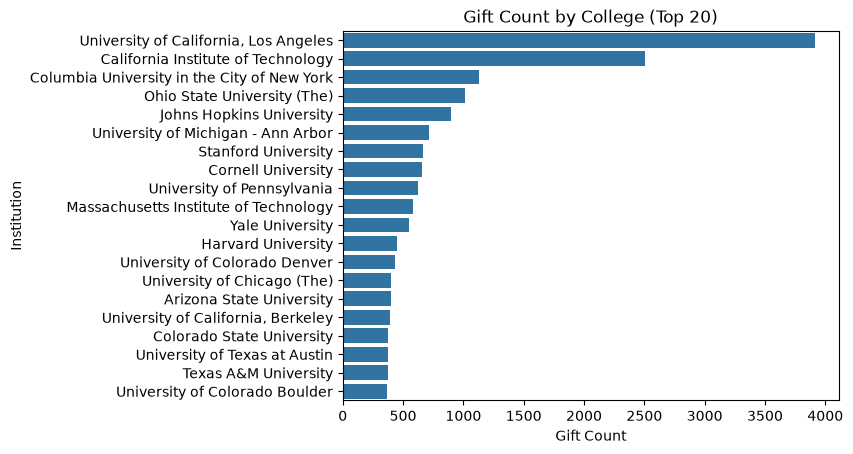

In [10]:
sns.barplot(
    data=college_count.head(20),
    x="Gift Count",
    y="Institution Name"
)

plt.xlabel("Gift Count")
plt.ylabel("Institution")
plt.title("Gift Count by College (Top 20)")

plt.show()

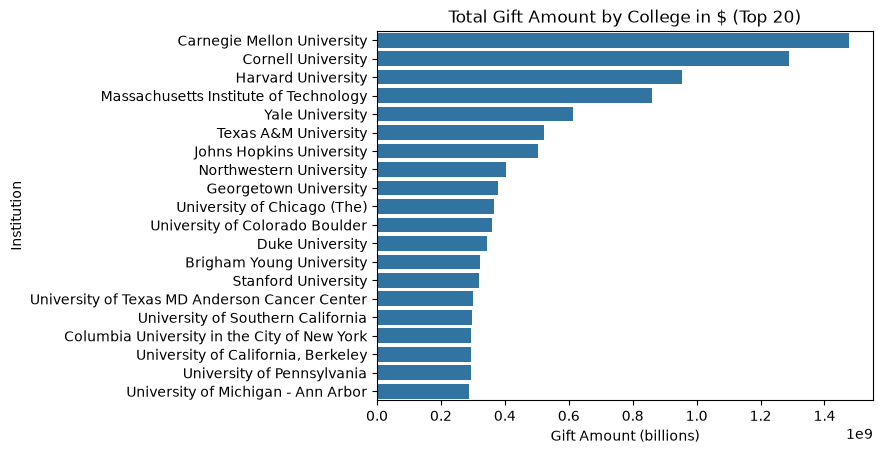

In [11]:
sns.barplot(
    data=college_money.head(20),
    x="Foreign Gift Amount",
    y="Institution Name"
)

plt.xlabel("Gift Amount (billions)")
plt.ylabel("Institution")
plt.title("Total Gift Amount by College in $ (Top 20)")

plt.show()

F) What is the average amount each university receives?

In [11]:
# F) What is the average amount each university receives?
display(college_money.head())

print(
    "Average amount each university receives: ",
    f"${college_money["Foreign Gift Amount"].mean():,.0f}",
)
print(
    "Median amount each university receives: ",
    f"${college_money["Foreign Gift Amount"].median():,.0f}",
)

,Institution Name,Foreign Gift Amount
0,Carnegie Mellon University,1477922504
1,Cornell University,1289937761
2,Harvard University,954803610
3,Massachusetts Institute of Technology,859071692
4,Yale University,613441311


Average amount each university receives:  $52,202,879
Median amount each university receives:  $6,486,792


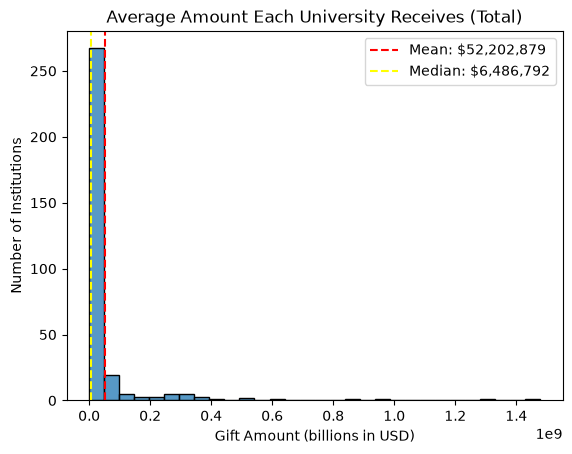

In [12]:
mean = college_money["Foreign Gift Amount"].mean()
median = college_money["Foreign Gift Amount"].median()

sns.histplot(
    data=college_money,
    x="Foreign Gift Amount",
    bins=30,
    edgecolor="black"
)

plt.axvline(
    mean,
    linestyle="--",
    label=f"Mean: ${mean:,.0f}",
    color="red"
)

plt.axvline(
    median,
    linestyle="--",
    label=f"Median: ${median:,.0f}",
    color="yellow"
)

plt.legend()

plt.xlabel("Gift Amount (billions in USD)")
plt.ylabel("Number of Institutions")
plt.title("Average Amount Each University Receives (Total)")

plt.show()

**Why the mean and median are different**:
The mean (*$52 million*) is much higher than the median (*$6.5 million*) because there are a few schools who receive substantially more money than the others, driving the average amount per school higher. By looking at the median (the middle value in a dataset), we can see that most schools' total amount actually falls closer to the $6.5 million mark.

G) What is the largest flow of money from a single country to a single university?

In [13]:
# First look at cross-tabulation for relationships between gifts from countries to universities
pd.crosstab(
    df["Country of Giftor"],
    df["Institution Name"]
)

Institution Name,Adelphi University,Albert Einstein College of Medicine,Alfred University,American University (The),Amherst College,Arizona State University,Auburn University Montgomery,Babson College,Ball State University,Barnard College,...,Wilkes University,William Marshall Rice University,Williams College,Winthrop University,Worcester Polytechnic Institute,Wright State University,Xavier University of Louisiana,Yale University,Yeshiva University,Young Americans College of the Performing Arts (The)
Country of Giftor,,,,,,,,,,,,,,,,,,,,,
AFGHANISTAN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AMERICAN SAMOA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ANGOLA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ANTIGUA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ARGENTINA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIRGIN ISLANDS (BRITISH),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
WALES,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
YEMEN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


*Note: Cross-tabulation form is very hard to interpret due to the table size and number of 0s. Visualization will be much easier to use for spotting larger trends.*

In [14]:
# Group by country name, institution name, then sum and sort
country_by_college = (
    df.groupby(["Country of Giftor", "Institution Name"])["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head()
    .reset_index()
)

display(country_by_college.head())

print("The largest flow of money from a single country to a single university:")
print(
    f"{country_by_college.iloc[0]["Country of Giftor"]} to {country_by_college.iloc[0]["Institution Name"]} (${country_by_college.iloc[0]["Foreign Gift Amount"]:,.0f})"
)

,Country of Giftor,Institution Name,Foreign Gift Amount
0,QATAR,Cornell University,1018473315
1,BERMUDA,Carnegie Mellon University,750000000
2,QATAR,Texas A&M University,504099350
3,QATAR,Carnegie Mellon University,425410702
4,QATAR,Georgetown University,327128310


The largest flow of money from a single country to a single university:
QATAR to Cornell University ($1,018,473,315)


H) Which are the top giftors to US academic institutions?

*I provided two options below: top giftors by total sum AND top giftors by total count*

In [28]:
# Group by giftor, then sum and sort (Top giftors by total amount)
df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(
    ascending=False
).reset_index().head(10)

,Giftor Name,Foreign Gift Amount
0,Qatar Foundation,1166503744
1,Qatar Foundation/Qatar National Res,796197000
2,Qatar Foundation for Education,373945215
3,Anonymous,338793629
4,Saudi Arabian Cultural Mission,275221475
5,HCL,190000000
6,Church of Jesus Christ of LDS,185203715
7,Emirates Institute for Advanced Sc,170641244
8,QIC,148355497
9,Anonymous #9,96334996


In [31]:
# Group by giftor, then count and sort (Top giftors by number of gifts given)
df.groupby("Giftor Name")["Gift Type"].count().sort_values(
    ascending=False
).reset_index().head(10)

,Giftor Name,Gift Type
0,Saudi Arabian Cultural Mission,480
1,Human Frontier Science Program,287
2,Anonymous,262
3,Qatar Foundation,261
4,Novartis Pharmaceuticals Corp,251
5,Royal Embassy of Saudi Arabia,210
6,Acerta Pharma B.V.,210
7,Contracting Party,143
8,Gwangju Institute of S&T,141
9,WSB Universities,140


**Bonus: Alluvial Plot**

In [16]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()